# 1. Data Loading and Splitting

In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split

pd.set_option('display.max_columns', 50)
sns.set_theme(style='whitegrid')

In [28]:
ames = fetch_openml(name='house_prices', as_frame=True, parser='auto')
df = ames.frame.copy()
df['SalePrice'] = pd.to_numeric(df['SalePrice'], errors='coerce')
df = df.dropna(subset=['SalePrice'])

df.tail()


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,...,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
1455,1456,60,RL,62.0,7917,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,Gilbert,Norm,Norm,1Fam,2Story,6,5,1999,2000,Gable,CompShg,VinylSd,VinylSd,...,1,TA,Attchd,1999.0,RFn,2,460,TA,TA,Y,0,40,0,0,0,0,NaN,NaN,NaN,0,8,2007,WD,Normal,175000
1456,1457,20,RL,85.0,13175,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,NWAmes,Norm,Norm,1Fam,1Story,6,6,1978,1988,Gable,CompShg,Plywood,Plywood,...,2,TA,Attchd,1978.0,Unf,2,500,TA,TA,Y,349,0,0,0,0,0,NaN,MnPrv,NaN,0,2,2010,WD,Normal,210000
1457,1458,70,RL,66.0,9042,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,9,1941,2006,Gable,CompShg,CemntBd,CmentBd,...,2,Gd,Attchd,1941.0,RFn,1,252,TA,TA,Y,0,60,0,0,0,0,NaN,GdPrv,Shed,2500,5,2010,WD,Normal,266500
1458,1459,20,RL,68.0,9717,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,NAmes,Norm,Norm,1Fam,1Story,5,6,1950,1996,Hip,CompShg,MetalSd,MetalSd,...,0,NaN,Attchd,1950.0,Unf,1,240,TA,TA,Y,366,0,112,0,0,0,NaN,NaN,NaN,0,4,2010,WD,Normal,142125
1459,1460,20,RL,75.0,9937,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,Edwards,Norm,Norm,1Fam,1Story,5,6,1965,1965,Gable,CompShg,HdBoard,HdBoard,...,0,NaN,Attchd,1965.0,Fin,1,276,TA,TA,Y,736,68,0,0,0,0,NaN,NaN,NaN,0,6,2008,WD,Normal,147500


In [29]:
X = df.drop(columns=['SalePrice', 'Id'])
y = df['SalePrice']

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.4, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

print(X_train.shape, X_val.shape, X_test.shape)


(876, 79) (292, 79) (292, 79)


# 2. Feature Selection

In [30]:
X.head()

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,...,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition
0,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,...,Typ,0,NaN,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal
1,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,None,...,Typ,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal
2,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,...,Typ,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal
3,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,'Wd Sdng','Wd Shng',None,...,Typ,1,Gd,Detchd,1998.0,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml
4,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,...,Typ,1,TA,Attchd,2000.0,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal


In [30]:
numerical_cols = X_train.select_dtypes(include=np.number).columns.tolist()
categorical_cols = X_train.select_dtypes(exclude=np.number).columns.tolist()

print(f"Numerical columns: {numerical_cols}")
print(f"Categorical columns: {categorical_cols}")

Numerical columns: ['MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd', 'Fireplaces', 'GarageYrBlt', 'GarageCars', 'GarageArea', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'MiscVal', 'MoSold', 'YrSold']
Categorical columns: ['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual', 'Functional', 'FireplaceQu', 'GarageType', 

In [32]:
X_train.describe().T

,count,mean,std,min,25%,50%,75%,max
MSSubClass,876.0,57.808219,43.687092,20.0,20.00,50.0,70.00,190.0
LotFrontage,709.0,69.747532,26.157493,21.0,59.00,68.0,80.00,313.0
LotArea,876.0,10789.401826,12129.787810,1300.0,7466.25,9528.0,11515.50,215245.0
OverallQual,876.0,6.100457,1.368695,1.0,5.00,6.0,7.00,10.0
OverallCond,876.0,5.560502,1.109849,1.0,5.00,5.0,6.00,9.0
YearBuilt,876.0,1970.731735,30.820883,1872.0,1952.75,1972.0,2001.00,2010.0
YearRemodAdd,876.0,1984.601598,20.933526,1950.0,1965.75,1994.0,2004.00,2010.0
MasVnrArea,874.0,103.935927,171.436303,0.0,0.00,0.0,169.50,1378.0
BsmtFinSF1,876.0,449.519406,463.462631,0.0,0.00,397.0,725.00,5644.0
BsmtFinSF2,876.0,42.158676,152.313830,0.0,0.00,0.0,0.00,1120.0


In [31]:
missing_cols = X_train.isnull().sum()
missing_cols = missing_cols[missing_cols > 0]

print("Columns with missing values and their counts in X_train:")
print(missing_cols)

missing_numerical_cols = missing_cols[X_train[missing_cols.index].dtypes != 'object'].index.tolist()
missing_categorical_cols = missing_cols[X_train[missing_cols.index].dtypes == 'object'].index.tolist()

print(f"\nNumerical columns with missing values: {missing_numerical_cols}")
print(f"Categorical columns with missing values: {missing_categorical_cols}")

Columns with missing values and their counts in X_train:
LotFrontage     167
Alley           818
MasVnrType        2
MasVnrArea        2
BsmtQual         22
BsmtCond         22
BsmtExposure     22
BsmtFinType1     22
BsmtFinType2     22
Electrical        1
FireplaceQu     420
GarageType       46
GarageYrBlt      46
GarageFinish     46
GarageQual       46
GarageCond       46
PoolQC          872
Fence           709
MiscFeature     839
dtype: int64

Numerical columns with missing values: ['LotFrontage', 'Alley', 'MasVnrType', 'MasVnrArea', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'Electrical', 'FireplaceQu', 'GarageType', 'GarageYrBlt', 'GarageFinish', 'GarageQual', 'GarageCond', 'PoolQC', 'Fence', 'MiscFeature']
Categorical columns with missing values: []


In [32]:
df_corr_with_saleprice = pd.concat([X_train[numerical_cols], y_train], axis=1)

correlations = df_corr_with_saleprice.corr()['SalePrice'].drop('SalePrice').sort_values(ascending=False).round(2)

print("Correlation of numerical features with SalePrice:")
print(correlations)

Correlation of numerical features with SalePrice:
OverallQual      0.78
GrLivArea        0.67
GarageCars       0.64
GarageArea       0.62
TotalBsmtSF      0.58
1stFlrSF         0.57
FullBath         0.54
YearRemodAdd     0.52
TotRmsAbvGrd     0.51
YearBuilt        0.51
GarageYrBlt      0.47
Fireplaces       0.46
MasVnrArea       0.45
BsmtFinSF1       0.36
LotFrontage      0.33
WoodDeckSF       0.33
2ndFlrSF         0.29
HalfBath         0.28
LotArea          0.27
OpenPorchSF      0.26
BsmtFullBath     0.24
BsmtUnfSF        0.21
BedroomAbvGr     0.15
ScreenPorch      0.14
3SsnPorch        0.08
MoSold           0.07
PoolArea         0.05
LowQualFinSF     0.01
BsmtFinSF2       0.01
MiscVal          0.00
YrSold          -0.02
BsmtHalfBath    -0.04
OverallCond     -0.06
MSSubClass      -0.10
KitchenAbvGr    -0.14
EnclosedPorch   -0.14
Name: SalePrice, dtype: float64


Top 10 features correlated with SalePrice: ['OverallQual', 'GrLivArea', 'GarageCars', 'GarageArea', 'TotalBsmtSF', '1stFlrSF', 'FullBath', 'YearRemodAdd', 'TotRmsAbvGrd', 'YearBuilt']


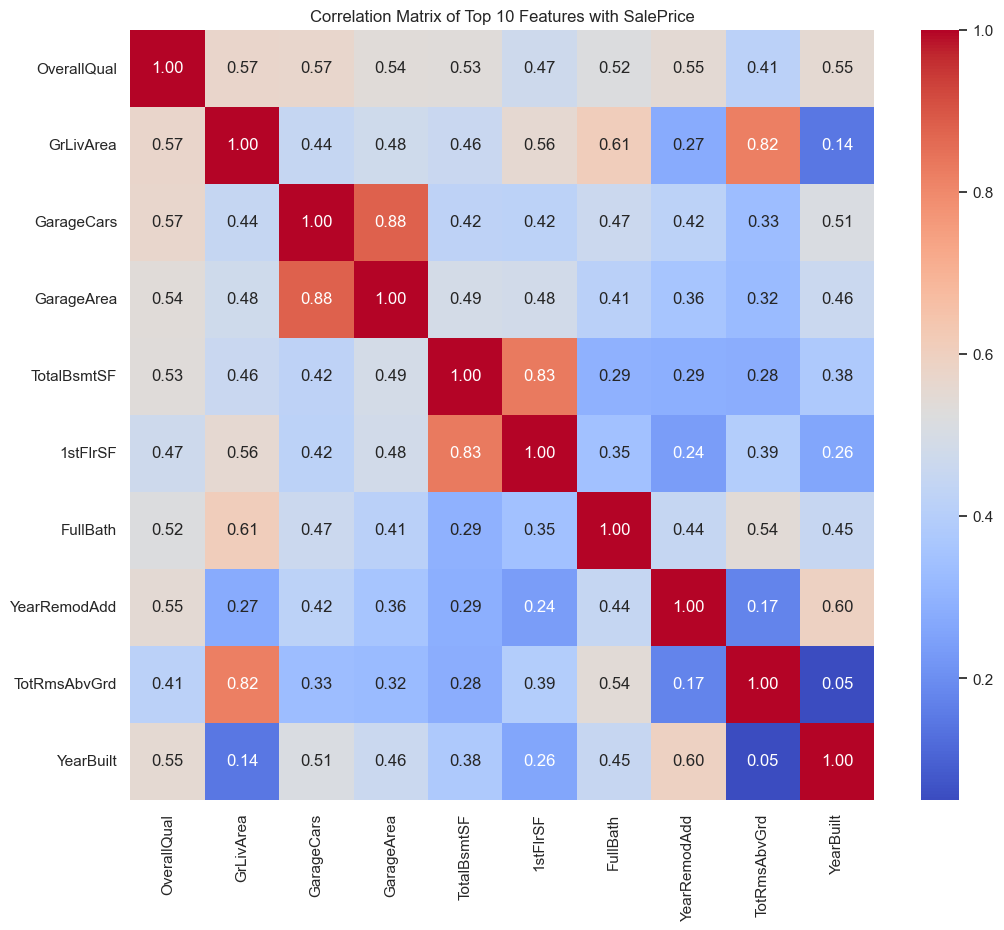

In [33]:

correlations_with_saleprice = df_corr_with_saleprice.corr()['SalePrice'].abs().sort_values(ascending=False)

top_10_features = correlations_with_saleprice.drop('SalePrice').head(10).index.tolist()

print(f"Top 10 features correlated with SalePrice: {top_10_features}")

plt.figure(figsize=(12, 10))
sns.heatmap(X_train[top_10_features].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Top 10 Features with SalePrice')
plt.show()

## Selected Numerical Features

After combining the chart results and domain knowledge, the following numerical features were selected for modeling:

*   `OverallQual`
*   `GrLivArea`
*   `GarageCars`
*   `1stFlrSF`
*   `FullBath`
*   `YearRemodAdd`
*   `TotRmsAbvGrd`
*   `YearBuilt`

In [36]:
print(f'Total categorical columns: {len(categorical_cols)}')
for col in categorical_cols:
    print(f'  {col}: {X_train[col].nunique()} unique -> {X_train[col].unique()[:5]}')

Total categorical columns: 43
  MSZoning: 5 unique -> <StringArray>
['RM', 'RL', 'FV', 'RH', ''C (all)'']
Length: 5, dtype: str
  Street: 2 unique -> <StringArray>
['Pave', 'Grvl']
Length: 2, dtype: str
  Alley: 2 unique -> <StringArray>
['Grvl', nan, 'Pave']
Length: 3, dtype: str
  LotShape: 4 unique -> <StringArray>
['Reg', 'IR1', 'IR2', 'IR3']
Length: 4, dtype: str
  LandContour: 4 unique -> <StringArray>
['Lvl', 'Bnk', 'HLS', 'Low']
Length: 4, dtype: str
  Utilities: 2 unique -> <StringArray>
['AllPub', 'NoSeWa']
Length: 2, dtype: str
  LotConfig: 5 unique -> <StringArray>
['Inside', 'CulDSac', 'Corner', 'FR2', 'FR3']
Length: 5, dtype: str
  LandSlope: 3 unique -> <StringArray>
['Gtl', 'Mod', 'Sev']
Length: 3, dtype: str
  Neighborhood: 25 unique -> <StringArray>
['OldTown', 'BrkSide', 'NWAmes', 'Mitchel', 'CollgCr']
Length: 5, dtype: str
  Condition1: 9 unique -> <StringArray>
['Norm', 'Feedr', 'PosA', 'RRAn', 'PosN']
Length: 5, dtype: str
  Condition2: 6 unique -> <StringArray>
[

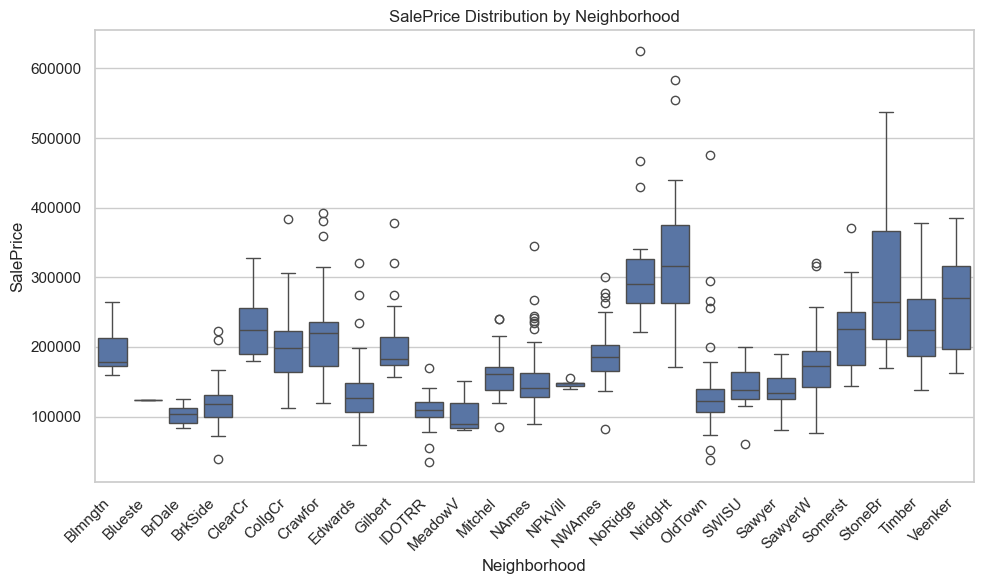

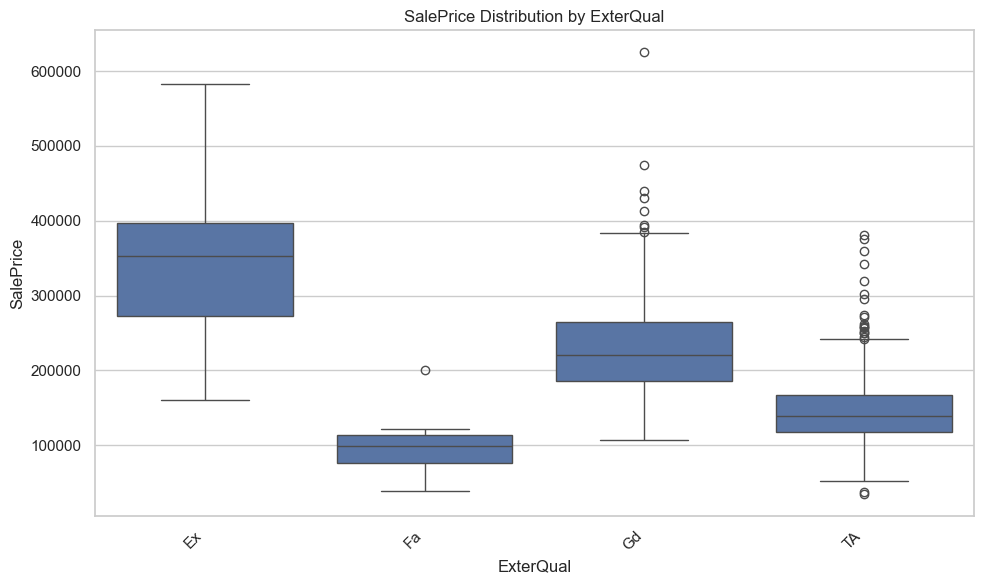

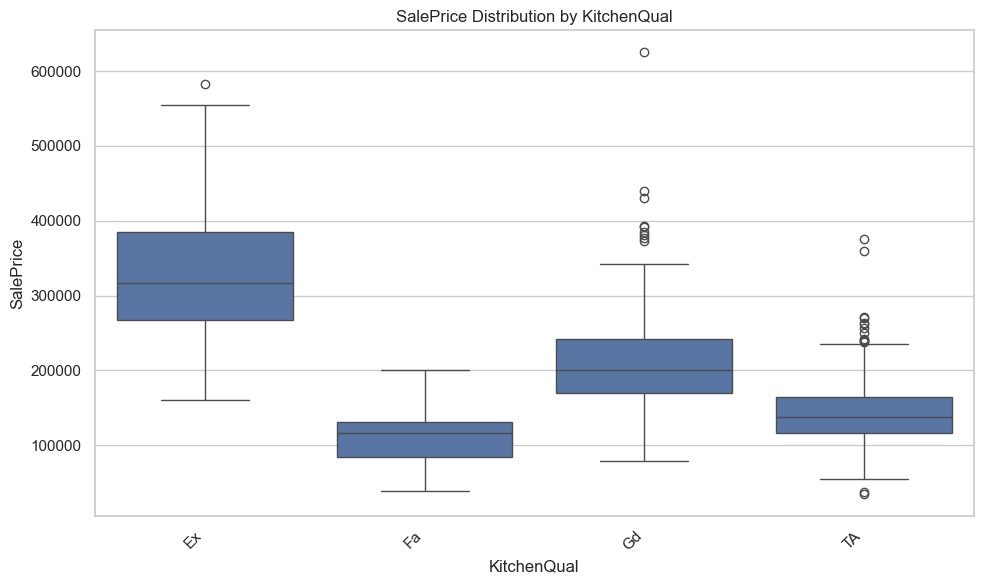

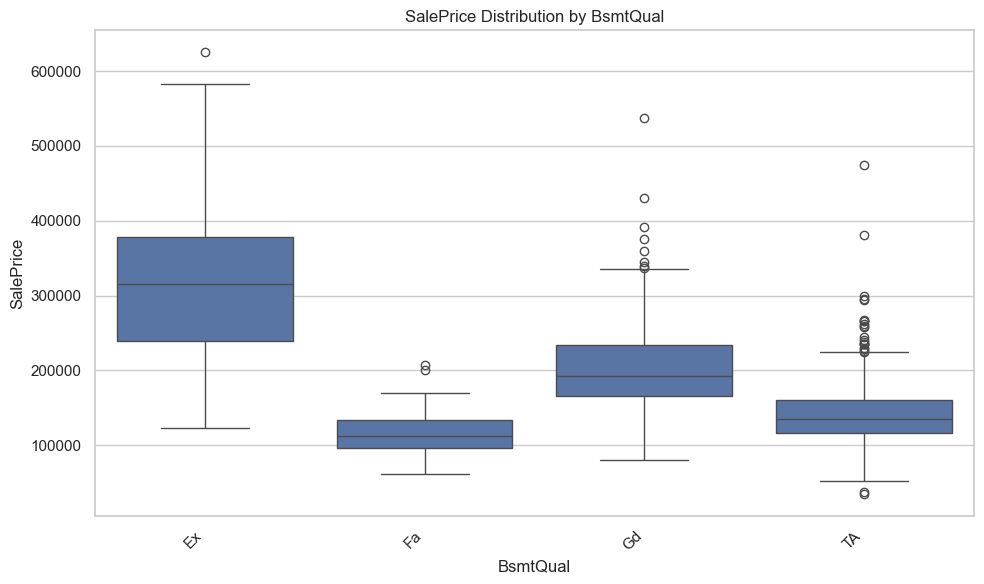

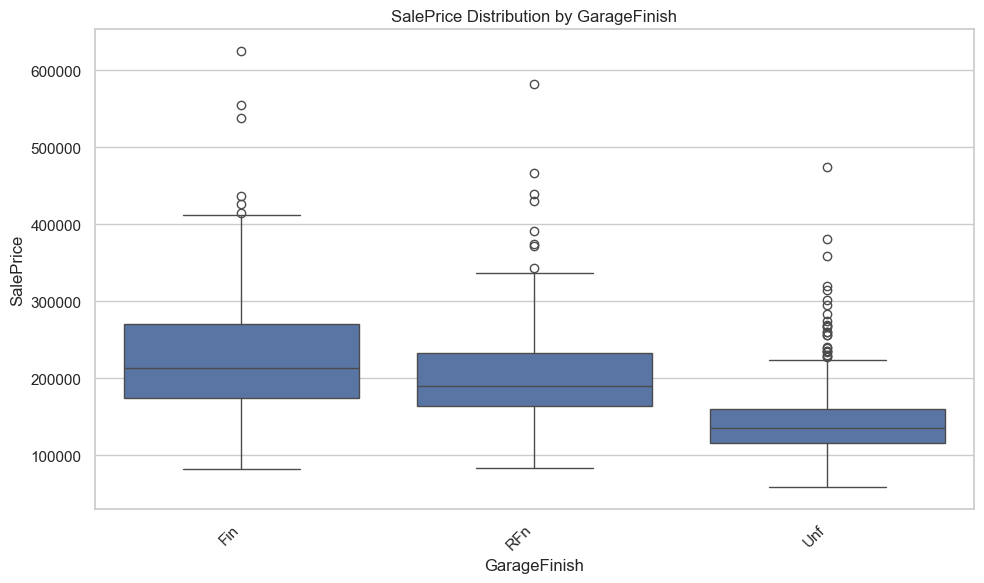

In [37]:
def plot_categorical_vs_saleprice(df, categorical_col):
    plt.figure(figsize=(10, 6))
    sns.boxplot(x=categorical_col, y='SalePrice', data=df.sort_values(by=categorical_col))
    plt.title(f'SalePrice Distribution by {categorical_col}')
    plt.xlabel(categorical_col)
    plt.ylabel('SalePrice')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

df_train = pd.concat([X_train, y_train], axis=1)


plot_categorical_vs_saleprice(df_train, 'Neighborhood')

plot_categorical_vs_saleprice(df_train, 'ExterQual')

plot_categorical_vs_saleprice(df_train, 'KitchenQual')

plot_categorical_vs_saleprice(df_train, 'BsmtQual')

plot_categorical_vs_saleprice(df_train, 'GarageFinish')


## Selected Categorical Features

After combining the chart results and domain knowledge, the following categorical features were selected for modeling:

*   `Neighborhood`
*   `ExterQual`
*   `KitchenQual`
*   `BsmtQual`


# 3. Pipeline Building

In [ ]:
import joblib

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [8]:
selected_features = [
    'OverallQual', 'GrLivArea', 'GarageCars', '1stFlrSF',
    'YearBuilt', 'FullBath', 'TotRmsAbvGrd', 'YearRemodAdd',
    'Neighborhood', 'ExterQual', 'KitchenQual', 'BsmtQual'
]


In [9]:
X_train[selected_features].describe().T

,count,mean,std,min,25%,50%,75%,max
OverallQual,876.0,6.100457,1.368695,1.0,5.00,6.0,7.00,10.0
GrLivArea,876.0,1522.293379,527.668534,334.0,1141.75,1465.0,1786.25,5642.0
GarageCars,876.0,1.771689,0.723750,0.0,1.00,2.0,2.00,4.0
1stFlrSF,876.0,1162.106164,387.661677,334.0,882.00,1095.0,1378.75,4692.0
YearBuilt,876.0,1970.731735,30.820883,1872.0,1952.75,1972.0,2001.00,2010.0
FullBath,876.0,1.581050,0.546412,0.0,1.00,2.0,2.00,3.0
TotRmsAbvGrd,876.0,6.518265,1.623649,2.0,5.00,6.0,7.00,14.0
YearRemodAdd,876.0,1984.601598,20.933526,1950.0,1965.75,1994.0,2004.00,2010.0


In [10]:
X_train = X_train[selected_features]
X_train.head()

,OverallQual,GrLivArea,GarageCars,1stFlrSF,YearBuilt,FullBath,TotRmsAbvGrd,YearRemodAdd,Neighborhood,ExterQual,KitchenQual,BsmtQual
314,7,1641,2,832,1925,1,6,1990,OldTown,TA,Ex,TA
442,5,1573,2,1128,1930,2,8,1992,BrkSide,TA,TA,TA
319,7,1472,2,1472,1980,2,6,1980,NWAmes,TA,TA,Gd
767,6,1750,1,983,1940,2,7,1985,Mitchel,TA,TA,Gd
756,8,1768,2,866,2007,2,7,2007,CollgCr,Gd,Gd,Gd


In [34]:
numeric_features = [
    'OverallQual', 'GrLivArea', 'GarageCars', '1stFlrSF',
    'YearBuilt', 'FullBath', 'TotRmsAbvGrd', 'YearRemodAdd'
]


nominal_features = ['Neighborhood']

ordinal_features = ['ExterQual', 'KitchenQual', 'BsmtQual']

In [35]:
ordinal_categories = [
    ['Po', 'Fa', 'TA', 'Gd', 'Ex'],
    ['Po', 'Fa', 'TA', 'Gd', 'Ex'],
    ['Po', 'Fa', 'TA', 'Gd', 'Ex']
]

In [36]:
numeric_transformer = Pipeline(steps =[('imputer', SimpleImputer(strategy='mean')),
                                         ('scaler', StandardScaler())
                                         ])
nominal_transformer = Pipeline(steps=[('imputer', SimpleImputer(strategy='most_frequent')),
                                       ('onehot', OneHotEncoder(handle_unknown='ignore'))])
ordinal_transformer = Pipeline(steps=[('imputer', SimpleImputer(strategy='most_frequent')),
                                     ('ordinal', OrdinalEncoder(categories=ordinal_categories))])

In [37]:
preprocessor = ColumnTransformer(transformers=[('num', numeric_transformer, numeric_features),
                                               ('nom', nominal_transformer, nominal_features),
                                               ('ord', ordinal_transformer, ordinal_features)], remainder='drop')

In [38]:
pipe_lr = Pipeline(steps=[('preprocessor', preprocessor),
                          ('model', LinearRegression())
                          ])
pipe_rf = Pipeline(steps=[('preprocessor', preprocessor),
                          ('model', RandomForestRegressor(n_estimators=200, random_state=42))
                          ])
pipe_xgb = Pipeline(steps=[('preprocessor', preprocessor),
                           ('model', XGBRegressor(
                               n_estimators=500,
                               learning_rate=0.05,
                               max_depth=4,
                               subsample=0.8,
                               colsample_bytree=0.8,
                               reg_lambda=1.0,
                               objective='reg:squarederror',
                               random_state=42,
                               n_jobs=-1
                           ))
                           ])

# 4. Model training and Evalutation

In [39]:
pipe_lr.fit(X_train, y_train)

lr_train_pred = pipe_lr.predict(X_train)
lr_val_pred = pipe_lr.predict(X_val)

lr_train_mae = mean_absolute_error(y_train, lr_train_pred)
lr_train_rmse = np.sqrt(mean_squared_error(y_train, lr_train_pred))
lr_train_r2 = r2_score(y_train, lr_train_pred)

lr_val_mae = mean_absolute_error(y_val, lr_val_pred)
lr_val_rmse = np.sqrt(mean_squared_error(y_val, lr_val_pred))
lr_val_r2 = r2_score(y_val, lr_val_pred)

print(f"Linear Regression -- Train MAE: {lr_train_mae:.0f} | RMSE: {lr_train_rmse:.0f} | R2: {lr_train_r2:.3f}")
print(f"Linear Regression -- Validation MAE: {lr_val_mae:.0f} | RMSE: {lr_val_rmse:.0f} | R2: {lr_val_r2:.3f}")


Linear Regression -- Train MAE: 21262 | RMSE: 33072 | R2: 0.807
Linear Regression -- Validation MAE: 23848 | RMSE: 41421 | R2: 0.818


In [41]:
pipe_rf.fit(X_train, y_train)

rf_train_pred = pipe_rf.predict(X_train)
rf_val_pred = pipe_rf.predict(X_val)

rf_train_mae = mean_absolute_error(y_train, rf_train_pred)
rf_train_rmse = np.sqrt(mean_squared_error(y_train, rf_train_pred))
rf_train_r2 = r2_score(y_train, rf_train_pred)

rf_val_mae = mean_absolute_error(y_val, rf_val_pred)
rf_val_rmse = np.sqrt(mean_squared_error(y_val, rf_val_pred))
rf_val_r2 = r2_score(y_val, rf_val_pred)

print(f"Random Forest -- Train MAE: {rf_train_mae:.0f} | RMSE: {rf_train_rmse:.0f} | R2: {rf_train_r2:.3f}")
print(f"Random Forest -- Validation MAE: {rf_val_mae:.0f} | RMSE: {rf_val_rmse:.0f} | R2: {rf_val_r2:.3f}")


Random Forest -- Train MAE: 7234 | RMSE: 12027 | R2: 0.975
Random Forest -- Validation MAE: 21208 | RMSE: 35849 | R2: 0.864


In [42]:
pipe_xgb.fit(X_train, y_train)

xgb_train_pred = pipe_xgb.predict(X_train)
xgb_val_pred = pipe_xgb.predict(X_val)

xgb_train_mae = mean_absolute_error(y_train, xgb_train_pred)
xgb_train_rmse = np.sqrt(mean_squared_error(y_train, xgb_train_pred))
xgb_train_r2 = r2_score(y_train, xgb_train_pred)

xgb_val_mae = mean_absolute_error(y_val, xgb_val_pred)
xgb_val_rmse = np.sqrt(mean_squared_error(y_val, xgb_val_pred))
xgb_val_r2 = r2_score(y_val, xgb_val_pred)

print(f"XGBoost -- Train MAE: {xgb_train_mae:.0f} | RMSE: {xgb_train_rmse:.0f} | R2: {xgb_train_r2:.3f}")
print(f"XGBoost -- Validation MAE: {xgb_val_mae:.0f} | RMSE: {xgb_val_rmse:.0f} | R2: {xgb_val_r2:.3f}")


XGBoost -- Train MAE: 7357 | RMSE: 9554 | R2: 0.984
XGBoost -- Validation MAE: 20779 | RMSE: 31865 | R2: 0.892


In [43]:
comparison = pd.DataFrame([
    {
        'model': 'LinearRegression',
        'train_mae': lr_train_mae,
        'train_rmse': lr_train_rmse,
        'train_r2': lr_train_r2,
        'val_mae': lr_val_mae,
        'val_rmse': lr_val_rmse,
        'val_r2': lr_val_r2,
    },
    {
        'model': 'RandomForest',
        'train_mae': rf_train_mae,
        'train_rmse': rf_train_rmse,
        'train_r2': rf_train_r2,
        'val_mae': rf_val_mae,
        'val_rmse': rf_val_rmse,
        'val_r2': rf_val_r2,
    },
    {
        'model': 'XGBoost',
        'train_mae': xgb_train_mae,
        'train_rmse': xgb_train_rmse,
        'train_r2': xgb_train_r2,
        'val_mae': xgb_val_mae,
        'val_rmse': xgb_val_rmse,
        'val_r2': xgb_val_r2,
    },
]).sort_values('val_rmse')
comparison


,model,train_mae,train_rmse,train_r2,val_mae,val_rmse,val_r2
2,XGBoost,7356.686523,9554.468274,0.983920,20778.972656,31865.033375,0.892178
1,RandomForest,7234.098745,12026.946203,0.974521,21208.393196,35848.709276,0.863534
0,LinearRegression,21261.610117,33071.592526,0.807343,23847.814873,41421.219812,0.817811


# 5. Model Selection and Saving

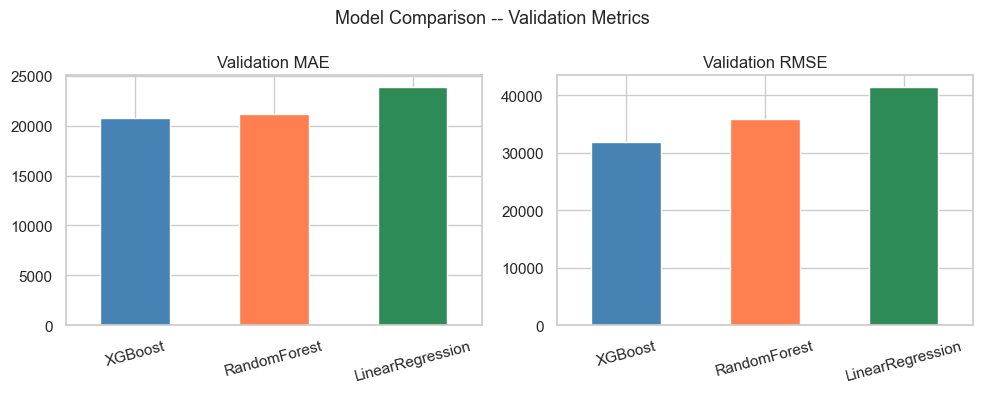

In [44]:
# Bar chart comparison of MAE and RMSE
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

comparison.plot(kind='bar', x='model', y='val_mae', ax=axes[0], legend=False, color=['steelblue', 'coral', 'seagreen'])
axes[0].set_title('Validation MAE')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=15)

comparison.plot(kind='bar', x='model', y='val_rmse', ax=axes[1], legend=False, color=['steelblue', 'coral', 'seagreen'])
axes[1].set_title('Validation RMSE')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=15)

plt.suptitle('Model Comparison -- Validation Metrics', fontsize=13)
plt.tight_layout()
plt.show()

In [45]:
print('Model selection summary:')
print(
    comparison[
        ['model', 'train_mae', 'train_rmse', 'train_r2', 'val_mae', 'val_rmse', 'val_r2']
    ].to_string(index=False)
)
print()
best_row = comparison.iloc[0]
print(f'Selected: {best_row["model"]}')
print(f'  Train R2: {best_row["train_r2"]:.3f}')
print(f'  Train RMSE: {best_row["train_rmse"]:.0f}')
print(f'  Val R2:   {best_row["val_r2"]:.3f}')
print(f'  Val RMSE: {best_row["val_rmse"]:.0f}')


Model selection summary:
           model    train_mae   train_rmse  train_r2      val_mae     val_rmse   val_r2
         XGBoost  7356.686523  9554.468274  0.983920 20778.972656 31865.033375 0.892178
    RandomForest  7234.098745 12026.946203  0.974521 21208.393196 35848.709276 0.863534
LinearRegression 21261.610117 33071.592526  0.807343 23847.814873 41421.219812 0.817811

Selected: XGBoost
  Train R2: 0.984
  Train RMSE: 9554
  Val R2:   0.892
  Val RMSE: 31865


In [48]:
from pathlib import Path



best_pipeline = pipe_xgb

SAVE_PATH = Path('../model/best_pipeline.joblib')
SAVE_PATH.parent.mkdir(parents=True, exist_ok=True)

joblib.dump(best_pipeline, SAVE_PATH)
print(f'Saved best model pipeline successfully to {SAVE_PATH.resolve()}.')

Saved best model pipeline successfully to C:\Users\Kayan\OneDrive\Desktop\SE Factory\week2_assignment\model\best_pipeline.joblib.


In [49]:
test_pred = best_pipeline.predict(X_test)
test_mae = mean_absolute_error(y_test, test_pred)
test_rmse = np.sqrt(mean_squared_error(y_test, test_pred))
test_r2 = r2_score(y_test, test_pred)

print('Final evaluation on the test set:')
print(f'Test MAE:  {test_mae:.0f}')
print(f'Test RMSE: {test_rmse:.0f}')
print(f'Test R2:   {test_r2:.3f}')


Final evaluation on the test set:
Test MAE:  17240
Test RMSE: 24478
Test R2:   0.877


# 6. Useful scripts

In [52]:
import json
from pathlib import Path

feature_constraints = {}

X_train = X_train[selected_features]

for col in X_train.columns:
    if pd.api.types.is_numeric_dtype(X_train[col]):
        feature_constraints[col] = {
            "type": "numerical",
            "min": float(X_train[col].min()),
            "max": float(X_train[col].max())
        }
    else:
        feature_constraints[col] = {
            "type": "categorical",
            "values": sorted(X_train[col].dropna().unique().tolist())
        }

output_path = Path("../model/feature_constraints.json")
output_path.parent.mkdir(parents=True, exist_ok=True)

with open(output_path, "w", encoding="utf-8") as f:
    json.dump(feature_constraints, f, indent=2)

print(f"Saved feature constraints to: {output_path.resolve()}")
feature_constraints


Saved feature constraints to: C:\Users\Kayan\OneDrive\Desktop\SE Factory\week2_assignment\model\feature_constraints.json


{'OverallQual': {'type': 'numerical', 'min': 1.0, 'max': 10.0},
 'GrLivArea': {'type': 'numerical', 'min': 334.0, 'max': 5642.0},
 'GarageCars': {'type': 'numerical', 'min': 0.0, 'max': 4.0},
 '1stFlrSF': {'type': 'numerical', 'min': 334.0, 'max': 4692.0},
 'YearBuilt': {'type': 'numerical', 'min': 1872.0, 'max': 2010.0},
 'FullBath': {'type': 'numerical', 'min': 0.0, 'max': 3.0},
 'TotRmsAbvGrd': {'type': 'numerical', 'min': 2.0, 'max': 14.0},
 'YearRemodAdd': {'type': 'numerical', 'min': 1950.0, 'max': 2010.0},
 'Neighborhood': {'type': 'categorical',
  'values': ['Blmngtn',
   'Blueste',
   'BrDale',
   'BrkSide',
   'ClearCr',
   'CollgCr',
   'Crawfor',
   'Edwards',
   'Gilbert',
   'IDOTRR',
   'MeadowV',
   'Mitchel',
   'NAmes',
   'NPkVill',
   'NWAmes',
   'NoRidge',
   'NridgHt',
   'OldTown',
   'SWISU',
   'Sawyer',
   'SawyerW',
   'Somerst',
   'StoneBr',
   'Timber',
   'Veenker']},
 'ExterQual': {'type': 'categorical', 'values': ['Ex', 'Fa', 'Gd', 'TA']},
 'KitchenQua

In [50]:
import json
from pathlib import Path

saleprice_summary_stats = {
    "SalePrice_mean": float(y_train.mean()),
    "SalePrice_median": float(y_train.median()),
    "SalePrice_min": float(y_train.min()),
    "SalePrice_max": float(y_train.max()),
    "SalePrice_std": float(y_train.std()),
    "SalePrice_q1": float(y_train.quantile(0.25)),
    "SalePrice_q3": float(y_train.quantile(0.75)),
}

output_path = Path("../model/training_summary_stats.json")
output_path.parent.mkdir(parents=True, exist_ok=True)

with open(output_path, "w", encoding="utf-8") as f:
    json.dump(saleprice_summary_stats, f, indent=2)

print(f"Saved training summary stats to: {output_path.resolve()}")
saleprice_summary_stats


Saved training summary stats to: C:\Users\Kayan\OneDrive\Desktop\SE Factory\week2_assignment\model\training_summary_stats.json


{'SalePrice_mean': 179921.78652968036,
 'SalePrice_median': 164945.0,
 'SalePrice_min': 34900.0,
 'SalePrice_max': 625000.0,
 'SalePrice_std': 75389.3939397168,
 'SalePrice_q1': 129000.0,
 'SalePrice_q3': 213625.0}